## Part A: Loadig data from before

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import fisher_exact,ttest_ind
import ast

In [13]:
main_df = pd.read_csv("./data/deliveries.csv")
df = main_df[main_df['phase'] == 'powerplay'].copy()

In [14]:
df.head()

,match_id,innings,ball,over,batting_team,bowling_team,striker,non_striker,bowler,runs_off_bat,extras,total_runs,wicket_flag,phase
0,598067.0,1st innings,0.1,0,Pune Warriors,Delhi Daredevils,RV Uthappa,AJ Finch,IK Pathan,0.0,0.0,0.0,0.0,powerplay
1,598067.0,1st innings,0.2,0,Pune Warriors,Delhi Daredevils,RV Uthappa,AJ Finch,IK Pathan,2.0,0.0,2.0,0.0,powerplay
2,598067.0,1st innings,0.3,0,Pune Warriors,Delhi Daredevils,RV Uthappa,AJ Finch,IK Pathan,4.0,0.0,4.0,0.0,powerplay
3,598067.0,1st innings,0.4,0,Pune Warriors,Delhi Daredevils,RV Uthappa,AJ Finch,IK Pathan,0.0,0.0,0.0,0.0,powerplay
4,598067.0,1st innings,0.5,0,Pune Warriors,Delhi Daredevils,RV Uthappa,AJ Finch,IK Pathan,1.0,0.0,1.0,0.0,powerplay


## Part B: EDA of Powerplay

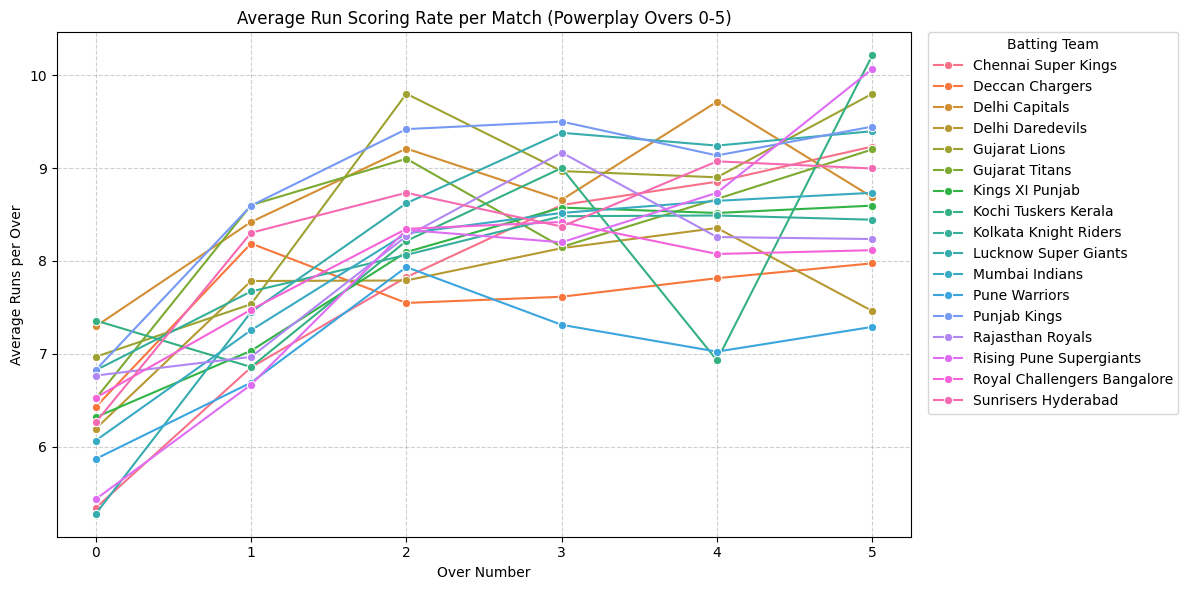

In [21]:
matches_per_team = df.groupby('batting_team')['match_id'].nunique()
runs_per_over = df.groupby(['batting_team', 'over'])['total_runs'].sum().reset_index()

runs_per_over['avg_runs'] = runs_per_over.apply(
    lambda x: x['total_runs'] / matches_per_team[x['batting_team']], axis=1
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=runs_per_over, x='over', y='avg_runs', hue='batting_team', marker='o')

plt.title("Average Run Scoring Rate per Match (Powerplay Overs 0-5)")
plt.xlabel("Over Number")
plt.ylabel("Average Runs per Over")

plt.legend(title='Batting Team', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

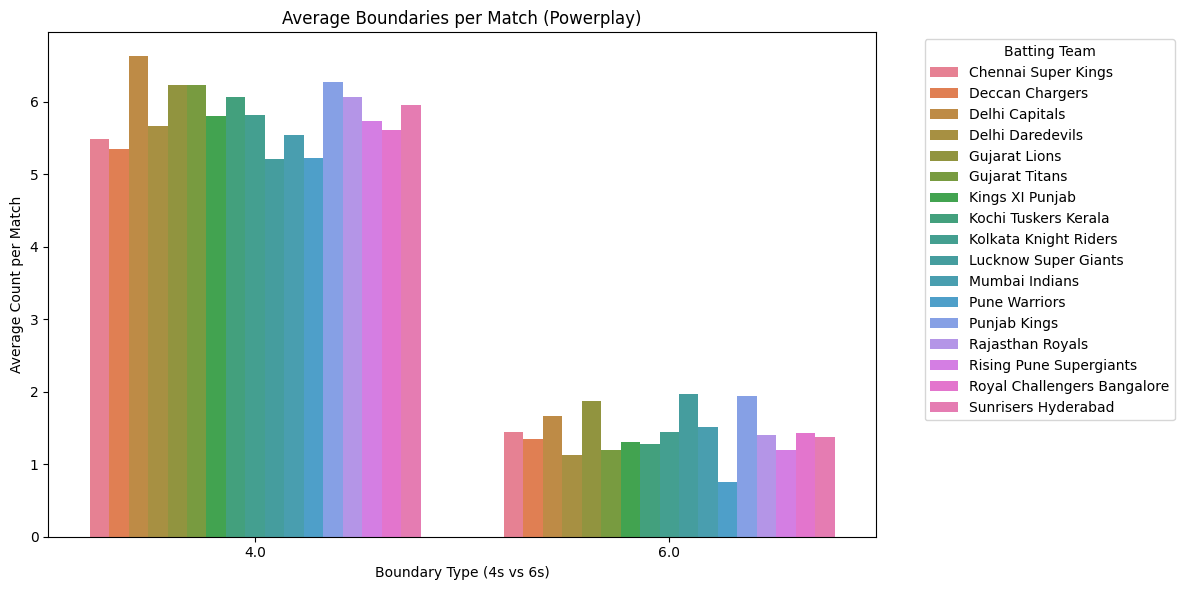

In [17]:
pp_boundaries = df[(df['runs_off_bat'].isin([4, 6])) & (df['phase'] == 'powerplay')]

boundary_counts = pp_boundaries.groupby(['batting_team', 'match_id', 'runs_off_bat']).size().reset_index(name='count')

total_matches = df.groupby('batting_team')['match_id'].nunique()
avg_boundaries = boundary_counts.groupby(['batting_team', 'runs_off_bat'])['count'].sum() / total_matches
avg_boundaries = avg_boundaries.reset_index(name='avg_per_match')

plt.figure(figsize=(12, 6))
sns.barplot(data=avg_boundaries, x='runs_off_bat', y='avg_per_match', hue='batting_team')

plt.title("Average Boundaries per Match (Powerplay)")
plt.xlabel("Boundary Type (4s vs 6s)")
plt.ylabel("Average Count per Match")

plt.legend(title='Batting Team', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

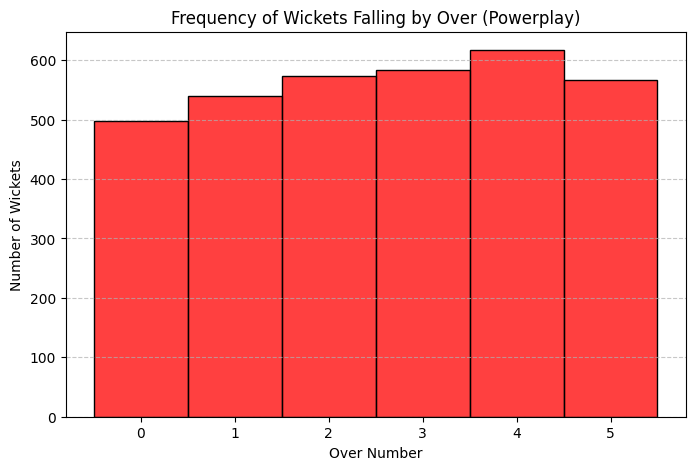

In [18]:
plt.figure(figsize=(8, 5))
wickets = df[df['wicket_flag'] == 1]

# Set bins=6 and binrange=(0, 6) so each bar represents exactly one over [0,1), [1,2)...
sns.histplot(data=wickets, x='over', bins=6, binrange=(0, 6), color='red', edgecolor='black')

plt.title("Frequency of Wickets Falling by Over (Powerplay)")
plt.xlabel("Over Number")
plt.ylabel("Number of Wickets")

# Align ticks to the center of the bars (0.5, 1.5, etc.) but label them 0, 1, 2...
plt.xticks(ticks=[i + 0.5 for i in range(6)], labels=[str(i) for i in range(6)])

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

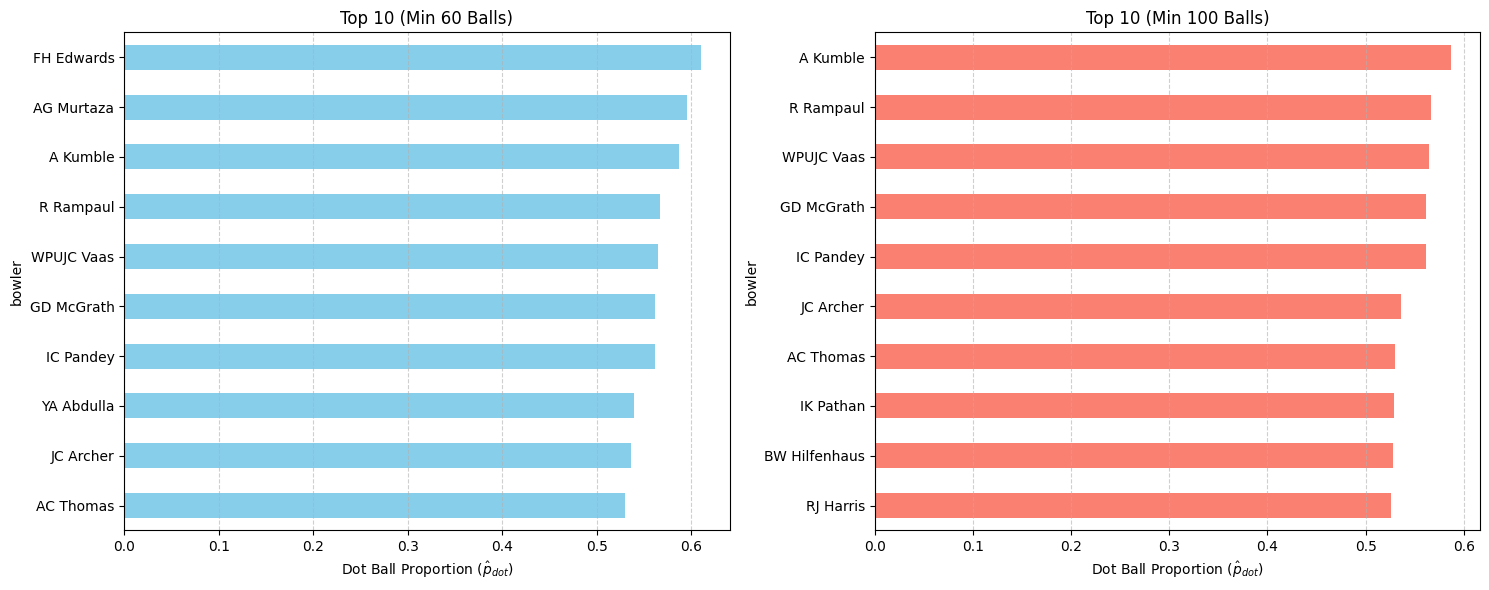

In [19]:
df['is_dot'] = (df['total_runs'] == 0).astype(int)
bowler_stats = df.groupby('bowler')['is_dot'].agg(['count', 'mean'])

# Thresholds: 60 vs 100
top_60 = bowler_stats[bowler_stats['count'] >= 60]['mean'].sort_values(ascending=False).head(10)
top_100 = bowler_stats[bowler_stats['count'] >= 100]['mean'].sort_values(ascending=False).head(10)

# 2. Plotting side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Left Plot: Min 60
top_60.plot(kind='barh', ax=ax1, color='skyblue')
ax1.set_title("Top 10 (Min 60 Balls)")
ax1.set_xlabel("Dot Ball Proportion ($\hat{p}_{dot}$)")
ax1.invert_yaxis()
ax1.grid(axis='x', linestyle='--', alpha=0.6)

# Right Plot: Min 100
top_100.plot(kind='barh', ax=ax2, color='salmon')
ax2.set_title("Top 10 (Min 100 Balls)")
ax2.set_xlabel("Dot Ball Proportion ($\hat{p}_{dot}$)")
ax2.invert_yaxis()
ax2.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

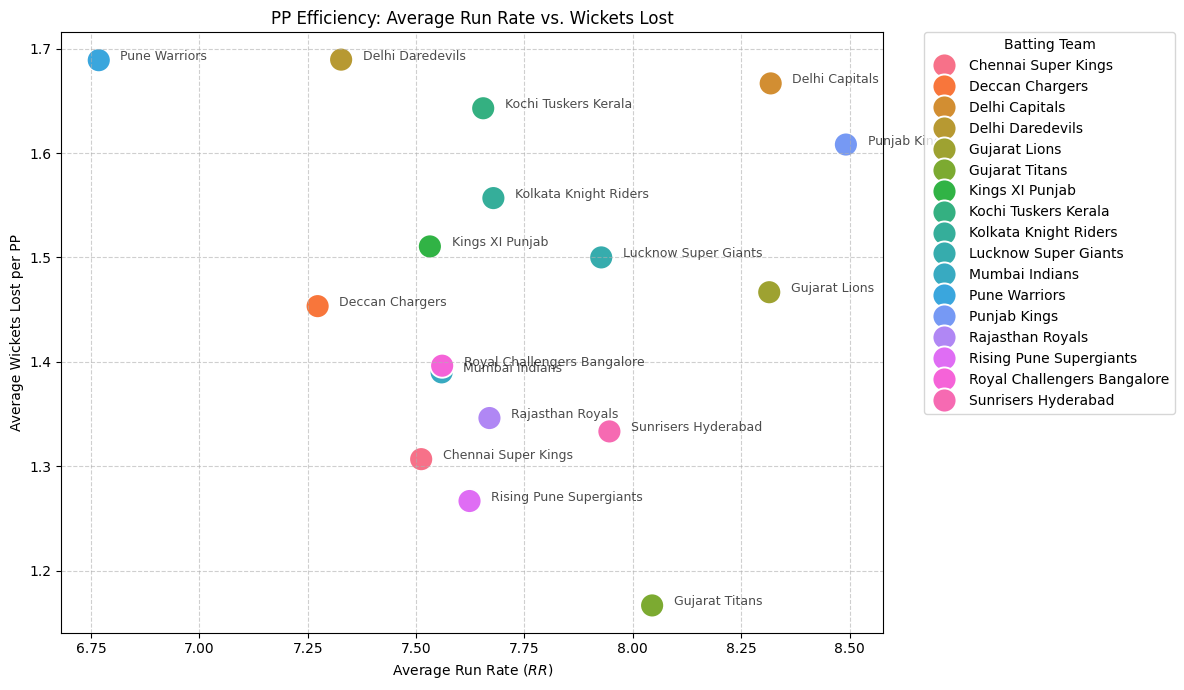

In [24]:
stats = df.groupby(['batting_team', 'match_id']).agg(
    total_runs=('total_runs', 'sum'),
    wickets=('wicket_flag', 'sum'),
    balls=('ball', 'count')
).reset_index()

# 2. Calculate match averages per team
team_efficiency = stats.groupby('batting_team').agg(
    avg_rr=('total_runs', lambda x: (x.sum() / stats.loc[x.index, 'balls'].sum()) * 6),
    avg_wickets=('wickets', 'mean')
).reset_index()

plt.figure(figsize=(12, 7))
# Increased point size (s=300) for better visibility
sns.scatterplot(data=team_efficiency, x='avg_rr', y='avg_wickets', hue='batting_team', s=300)

plt.title("PP Efficiency: Average Run Rate vs. Wickets Lost")
plt.xlabel("Average Run Rate ($RR$)")
plt.ylabel("Average Wickets Lost per PP")

# Move legend outside the plot
plt.legend(title='Batting Team', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

# Optional: Add annotations to the points directly to rely less on the legend
for i in range(team_efficiency.shape[0]):
    plt.text(team_efficiency.avg_rr[i]+0.05, team_efficiency.avg_wickets[i], 
             team_efficiency.batting_team[i], fontsize=9, alpha=0.7)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Part C: Cricketing Decision Using Hypothesis Tests

In [28]:
# Being ahrdcode RCB fans; this is out choice
players = ["CH Gayle", "V Kohli"]
player_a, player_b = players

In [37]:

results = {}
for p in players:
    p_data = df[df['striker'] == p]
    results[p] = {
        'n': len(p_data),
        'boundaries': p_data['runs_off_bat'].isin([4, 6]).sum(),
        'dismissals': p_data['wicket_flag'].sum()
    }

stats_list = []
for player, data in results.items():
    n = data['n']
    b = data['boundaries']
    d = data['dismissals']
    
    stats_list.append({
        "Player": player,
        "Balls Faced (n)": n,
        "Boundaries": b,
        "Dismissals": d,
        "Boundary Rate (p)": round(b / n, 4) if n > 0 else 0,
        "Dismissal Rate (q)": round(d / n, 4) if n > 0 else 0
    })

stats_df = pd.DataFrame(stats_list)
print(stats_df.to_string(index=False))

  Player  Balls Faced (n)  Boundaries  Dismissals  Boundary Rate (p)  Dismissal Rate (q)
CH Gayle             1851         412        66.0             0.2226              0.0357
 V Kohli             2555         467        74.0             0.1828              0.0290


#### Test 1: Boundary Rate (Z-Test)
 - *H0:* $p_A = p_B$
 - *H1:* $p_A > p_B$

In [33]:
# --- Test 1: Boundary Rate (Z-Test) ---
# H0: p_A = p_B vs H1: p_A > p_B
count = [results[player_a]['boundaries'], results[player_b]['boundaries']]
nobs = [results[player_a]['n'], results[player_b]['n']]

z_stat, p_val_bound = proportions_ztest(count, nobs, alternative='larger')
eff_size_bound = (count[0]/nobs[0]) - (count[1]/nobs[1])

print(f"Z stat: {z_stat:.2f}, p val: {p_val_bound:.6f}")
print(f"Effective size bound: {eff_size_bound}")

Z stat: 3.26, p val: 0.000551
Effective size bound: 0.039803522927787494


In [38]:
# Alpha = 0.05 significance level
if p_val_bound < 0.05:
    print("Reject H0: pA (CH Gayle) has a better boundary rate than pb (V Kholi)")
else:
    print("Fail to rject H0: pA (CH Gayle) does not have a better boundary rate than pb (V Kholi)")

Reject H0: pA (CH Gayle) has a better boundary rate than pb (V Kholi)


#### Test 2: Dismissal Rate (Fisher's Exact)
 - *H0:* $q_A = q_B$
 - *H1:* $q_A < q_B$

In [39]:
table = [
    [results[player_a]['dismissals'], results[player_a]['n'] - results[player_a]['dismissals']],
    [results[player_b]['dismissals'], results[player_b]['n'] - results[player_b]['dismissals']]
]
_, p_val_dismiss = fisher_exact(table, alternative='less')
eff_size_dismiss = (results[player_a]['dismissals']/nobs[0]) - (results[player_b]['dismissals']/nobs[1])

print(f"p value: {p_val_dismiss}")
print(f"Effective size bound: {eff_size_dismiss}")

p value: 0.9089822101655702
Effective size bound: 0.006693583940980758


In [44]:
count2 = [results[player_a]['dismissals'], results[player_b]['dismissals']]
nobs2 = [results[player_a]['n'], results[player_b]['n']]

proportions_ztest(count2, nobs2, alternative='smaller')

(np.float64(1.2502739387703996), np.float64(0.8944002524328412))

## In class

In [45]:
# Count unique match IDs for each team
matches_per_team = stats.groupby('batting_team')['match_id'].nunique().reset_index()
matches_per_team.columns = ['batting_team', 'matches_played']

print(matches_per_team.sort_values(by='matches_played', ascending=False))

                   batting_team  matches_played
10               Mumbai Indians             277
15  Royal Challengers Bangalore             270
8         Kolkata Knight Riders             264
0           Chennai Super Kings             251
13             Rajasthan Royals             234
16          Sunrisers Hyderabad             195
6               Kings XI Punjab             190
3              Delhi Daredevils             161
2                Delhi Capitals             105
1               Deccan Chargers              75
12                 Punjab Kings              74
5                Gujarat Titans              60
9          Lucknow Super Giants              58
11                Pune Warriors              45
4                 Gujarat Lions              30
14      Rising Pune Supergiants              30
7          Kochi Tuskers Kerala              14


### 1: Toss choices

In [51]:
info_df = pd.read_csv("./data/matches_info.csv")

In [53]:
info_df['team_list'] = info_df['teams'].apply(ast.literal_eval)
info_df['team1'] = info_df['team_list'].apply(lambda x: x[0])
info_df['team2'] = info_df['team_list'].apply(lambda x: x[1])

# 2. Find the luckiest team (Toss Wins / Total Matches Played)
toss_wins = info_df['toss_winner'].value_counts()
all_appearances = pd.concat([info_df['team1'], info_df['team2']])
total_matches = all_appearances.value_counts()

toss_ratio = (toss_wins / total_matches).fillna(0)
luckiest_team = toss_ratio.idxmax()
luckiest_pct = toss_ratio.max()

print(f"Luckiest Team: {luckiest_team} ({luckiest_pct:.2%})")
print(f"Is it significantly > 50%? {'Yes' if luckiest_pct > 0.55 else 'No'}") # cite: 65, 66

# 3. Toss Decision Preference
decision_pref = info_df['toss_decision'].value_counts(normalize=True)
print("\nToss Decision Preference:")
print(decision_pref) # cite: 67

Luckiest Team: Deccan Chargers (57.33%)
Is it significantly > 50%? Yes

Toss Decision Preference:
toss_decision
field    0.65355
bat      0.34645
Name: proportion, dtype: float64


In [54]:
toss_ratio.sort_values(ascending=False)

Deccan Chargers                0.573333
Kochi Tuskers Kerala           0.571429
Delhi Capitals                 0.547170
Mumbai Indians                 0.545126
Rajasthan Royals               0.540426
Chennai Super Kings            0.507937
Gujarat Lions                  0.500000
Punjab Kings                   0.500000
Delhi Daredevils               0.496894
Kolkata Knight Riders          0.484848
Sunrisers Hyderabad            0.484694
Gujarat Titans                 0.483333
Royal Challengers Bangalore    0.474074
Kings XI Punjab                0.447368
Pune Warriors                  0.434783
Rising Pune Supergiants        0.433333
Lucknow Super Giants           0.413793
Name: count, dtype: float64

In [55]:
toss_analysis = pd.DataFrame({
    'toss_wins': toss_wins,
    'total_matches': total_matches
}).fillna(0)

# 2. Calculate Ratio and P-value for each team
def calculate_toss_p_value(row):
    if row['total_matches'] == 0:
        return np.nan
    # proportions_ztest(count, nobs, value=0.5)
    stat, pval = proportions_ztest(row['toss_wins'], row['total_matches'], value=0.5)
    return pval

toss_analysis['toss_ratio'] = toss_analysis['toss_wins'] / toss_analysis['total_matches']
toss_analysis['p_value'] = toss_analysis.apply(calculate_toss_p_value, axis=1)

# 3. Format and Display
toss_analysis_sorted = toss_analysis.sort_values(by='toss_ratio', ascending=False)

print("Toss Luck Statistics (H0: p = 0.5):")
print(toss_analysis_sorted[['total_matches', 'toss_ratio', 'p_value']].to_string())

Toss Luck Statistics (H0: p = 0.5):
                             total_matches  toss_ratio   p_value
Deccan Chargers                         75    0.573333  0.199122
Kochi Tuskers Kerala                    14    0.571429  0.589154
Delhi Capitals                         106    0.547170  0.329244
Mumbai Indians                         277    0.545126  0.131488
Rajasthan Royals                       235    0.540426  0.213686
Chennai Super Kings                    252    0.507937  0.801035
Gujarat Lions                           30    0.500000  1.000000
Punjab Kings                            74    0.500000  1.000000
Delhi Daredevils                       161    0.496894  0.937182
Kolkata Knight Riders                  264    0.484848  0.622301
Sunrisers Hyderabad                    196    0.484694  0.668089
Gujarat Titans                          60    0.483333  0.796143
Royal Challengers Bangalore            270    0.474074  0.393570
Kings XI Punjab                        190    0.447368

In [57]:
decision_counts = info_df['toss_decision'].value_counts()
# Perform a simple Chi-square or binomial test if needed
_, p_val_decision = proportions_ztest(decision_counts['field'], decision_counts.sum(), value=0.5)

print(f"\nPreference for Fielding: {decision_counts.get('field', 0) / decision_counts.sum():.2%}")
print(f"Is this preference significant? (p={p_val_decision:.8f})")


Preference for Fielding: 65.36%
Is this preference significant? (p=0.00000000)


### 2 -> WPL

In [63]:
ipl_scores = main_df[main_df['innings'] == '1st innings'].groupby('match_id')['total_runs'].sum()
wpl_scores = pd.read_csv("./data/wpl.csv")['runs']

t_stat, p_val = ttest_ind(ipl_scores, wpl_scores, equal_var=False)

print(f"IPL Mean: {ipl_scores.mean():.2f}")
print(f"WPL Mean: {wpl_scores.mean():.2f}")
print(f"T-Test P-value: {p_val:.4f}") # cite: 69
print(t_stat)

IPL Mean: 167.02
WPL Mean: 160.61
T-Test P-value: 0.0630
1.8793021787382713


## 3 -> Best Death Over Batsmen

In [ ]:
death_df = main_df[main_df['phase'] == 'death'].copy()